# <font color="#418FDE" size="6.5" uppercase>**Data Issues and Fixes**</font>

>Last update: 20260406.
    
By the end of this Lecture, you will be able to:
- Diagnose data quality problems such as imbalance, outliers, noise, and drift in CE datasets. 
- Apply basic remediation techniques to improve model training data. 
- Design simple checks to monitor data distributions over time for deployed CE models. 


## **1. Class Imbalance Effects**

### **1.1. Rare Defect Cases**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_01_01.jpg?v=1775521550" width="250">



>* Critical defects are rare in infrastructure data.
>* Normal conditions dominate, hiding safety-relevant cases.

>* Rare defects are valuable but easily overlooked.
>* Diagnose beyond counts, contexts, and severity.

>* Large datasets can still hide defect scarcity.
>* Check rare cases for variety and reliability.



TensorFlow version: 2.21.0
Train counts normal, rare: [3268, 43]
Test counts normal, rare: [1452, 20]
Precision for rare defects: 0.667
Recall for rare defects: 0.1
Rare events are easy to miss.


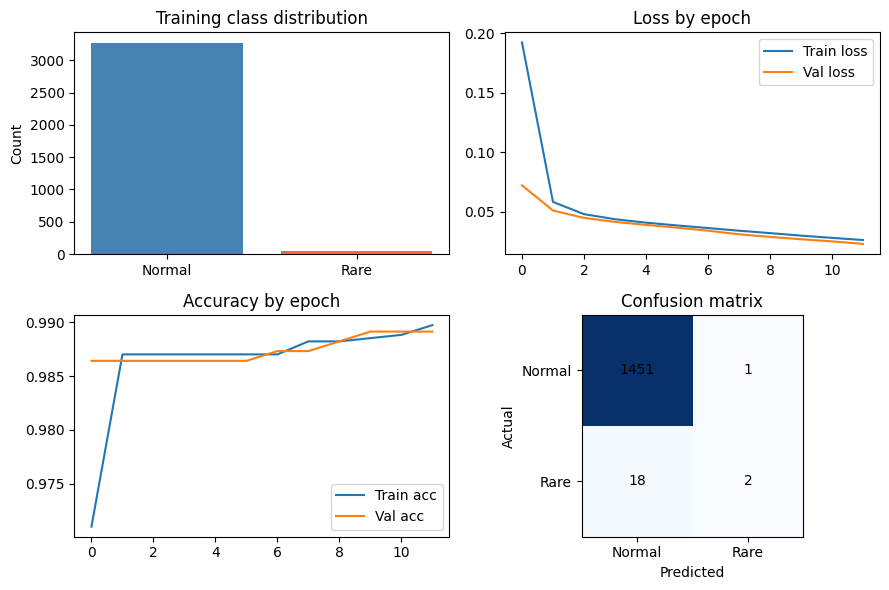

In [31]:
#@title Python Code - Rare Defect Cases

# Rare defects are hard to learn.
# This example mimics civil inspection imbalance.
# Small models can still miss defects.

# Install packages if Colab needs them.
# !pip install tensorflow==2.20.0 scikit-learn==1.8.0

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version once.
print("TensorFlow version:", tf.__version__)

# Download the training file.
!wget -q -O sat.trn https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/satimage/sat.trn

# Download the testing file.
!wget -q -O sat.tst https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/satimage/sat.tst

# Read both files safely.
train_df = pd.read_csv(
    "sat.trn",
    sep="\\s+",
    header=None
)
test_df = pd.read_csv(
    "sat.tst",
    sep="\\s+",
    header=None
)

# Combine rows into one table.
df = pd.concat([train_df, test_df], ignore_index=True)

# Check expected column count.
if df.shape[1] != 37:
    raise ValueError("Unexpected dataset shape.")

# Split features and labels.
X = df.iloc[:, :-1].copy()
y_raw = df.iloc[:, -1].copy()

# Make one class intentionally rare.
rare_class = 4
y = (y_raw == rare_class).astype(int)

# Keep only a small minority share.
minority_idx = np.where(y.values == 1)[0]
majority_idx = np.where(y.values == 0)[0]
keep_minority = minority_idx[: max(20, len(minority_idx) // 8)]
keep_idx = np.concatenate([majority_idx, keep_minority])

# Build the imbalanced teaching dataset.
X = X.iloc[keep_idx].reset_index(drop=True)
y = y.iloc[keep_idx].reset_index(drop=True)

# Convert values to float arrays.
X = X.astype("float32")
y = y.astype("float32")

# Create train and test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    random_state=7,
    stratify=y.values
)

# Create train and validation splits.
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=7,
    stratify=y_train
)

# Standardize using training statistics.
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-6
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Count class sizes clearly.
train_counts = np.bincount(y_train.astype(int), minlength=2)
test_counts = np.bincount(y_test.astype(int), minlength=2)

# Print a short imbalance summary.
print("Train counts normal, rare:", train_counts.tolist())
print("Test counts normal, rare:", test_counts.tolist())

# Build a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(36,)),
    tf.keras.layers.Dense(24, activation="relu"),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile with simple settings.
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train quietly for few epochs.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=32,
    verbose=0
)

# Predict rare defect probabilities.
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Compute simple evaluation values.
cm = confusion_matrix(y_test.astype(int), y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

# Print why imbalance matters.
print("Precision for rare defects:", round(float(precision), 3))
print("Recall for rare defects:", round(float(recall), 3))
print("Rare events are easy to miss.")

# Prepare one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Plot class distribution bars.
axes[0, 0].bar(["Normal", "Rare"], train_counts, color=["steelblue", "tomato"])
axes[0, 0].set_title("Training class distribution")
axes[0, 0].set_ylabel("Count")

# Plot training and validation loss.
axes[0, 1].plot(history.history["loss"], label="Train loss")
axes[0, 1].plot(history.history["val_loss"], label="Val loss")
axes[0, 1].set_title("Loss by epoch")
axes[0, 1].legend()

# Plot training and validation accuracy.
axes[1, 0].plot(history.history["accuracy"], label="Train acc")
axes[1, 0].plot(history.history["val_accuracy"], label="Val acc")
axes[1, 0].set_title("Accuracy by epoch")
axes[1, 0].legend()

# Plot the confusion matrix.
im = axes[1, 1].imshow(cm, cmap="Blues")
axes[1, 1].set_title("Confusion matrix")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(["Normal", "Rare"])
axes[1, 1].set_yticklabels(["Normal", "Rare"])
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")

# Write counts inside cells.
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm[i, j]), ha="center", va="center")

# Finish the teaching figure.
plt.tight_layout()
plt.show()



### **1.2. Resampling Strategies**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_01_02.jpg?v=1775521593" width="250">



>* Imbalance hides rare but critical defects.
>* Resampling reweights classes through under or oversampling.

>* Undersampling balances data but may lose variation.
>* Oversampling highlights rare cases but can overfit.

>* Resampling must reflect real data patterns.
>* Validate on original distributions to avoid leakage.



TensorFlow version: 2.21.0
Test minority count: 30
Baseline minority recall: 0.167
Oversampled minority recall: 0.867
Undersampled minority recall: 0.9
Baseline accuracy: 0.962
Oversampled accuracy: 0.898
Undersampled accuracy: 0.803


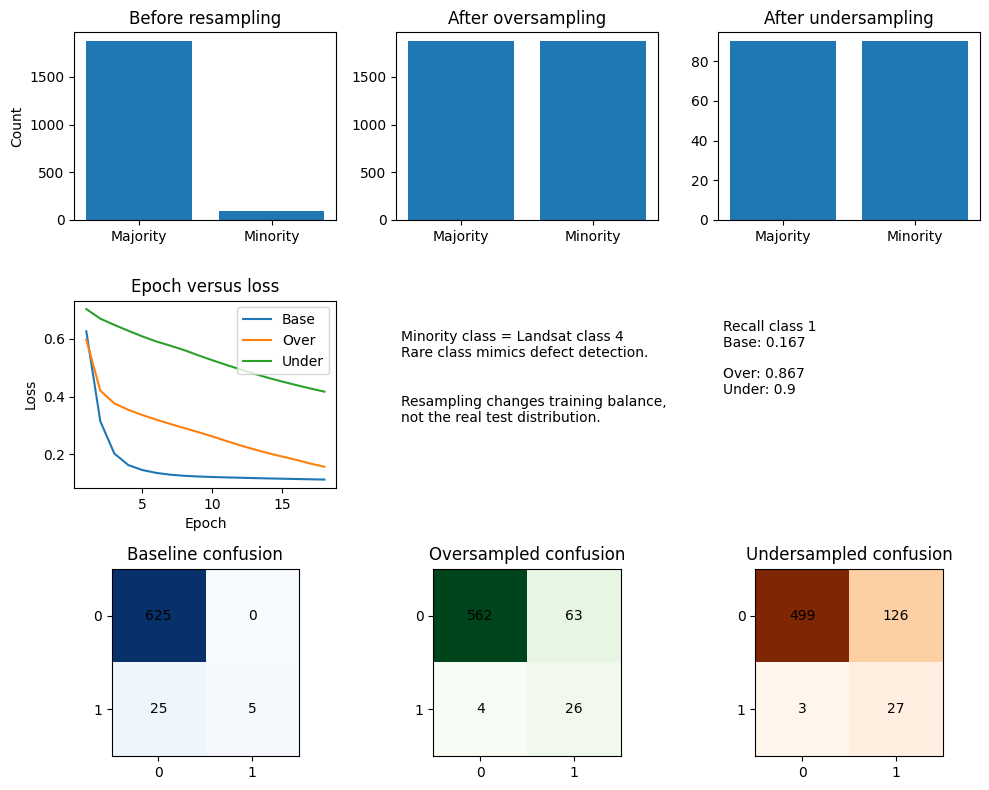

In [2]:
#@title Python Code - Resampling Strategies

# This notebook shows simple resampling ideas.
# We use Landsat data for imbalance.
# TensorFlow compares before and after balancing.

# !pip install ucimlrepo

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Print one short framework line.
print("TensorFlow version:", tf.__version__)

# Download the Landsat dataset.
!wget -q -O sat.trn "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/satimage/sat.trn"
!wget -q -O sat.tst "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/satimage/sat.tst"

# Read training and test files.
train_df = pd.read_csv(
    "sat.trn", sep="\\s+", header=None
)
test_df = pd.read_csv(
    "sat.tst", sep="\\s+", header=None
)

# Combine both parts together.
full_df = pd.concat(
    [train_df, test_df], ignore_index=True
)

# Name feature and target columns.
feature_names = []
for i in range(36):
    feature_names.append("band_" + str(i + 1))

full_df.columns = feature_names + ["class_id"]

# Build a binary engineering style task.
full_df["target"] = 0
full_df.loc[full_df["class_id"] == 4, "target"] = 1

# Create a stronger imbalance deliberately.
majority_df = full_df[full_df["target"] == 0].copy()
minority_df = full_df[full_df["target"] == 1].copy()

majority_keep = majority_df.sample(
    n=2500, random_state=7
)
minority_keep = minority_df.sample(
    n=120, random_state=7
)

imbalanced_df = pd.concat(
    [majority_keep, minority_keep], ignore_index=True
)
imbalanced_df = imbalanced_df.sample(
    frac=1.0, random_state=7
).reset_index(drop=True)

# Split data before any resampling.
X = imbalanced_df[feature_names].copy()
y = imbalanced_df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=7
)

# Check basic sizes safely.
if len(X_train) < 20:
    raise ValueError("Training set is too small.")

# Build a training dataframe.
train_data = X_train.copy()
train_data["target"] = y_train.values

# Count classes before balancing.
before_counts = train_data["target"].value_counts().sort_index()

# Separate majority and minority rows.
train_majority = train_data[train_data["target"] == 0].copy()
train_minority = train_data[train_data["target"] == 1].copy()

# Random oversampling with pandas.
oversampled_minority = train_minority.sample(
    n=len(train_majority), replace=True, random_state=7
)
oversampled_data = pd.concat(
    [train_majority, oversampled_minority], ignore_index=True
)
oversampled_data = oversampled_data.sample(
    frac=1.0, random_state=7
).reset_index(drop=True)

# Random undersampling with pandas.
undersampled_majority = train_majority.sample(
    n=len(train_minority), random_state=7
)
undersampled_data = pd.concat(
    [undersampled_majority, train_minority], ignore_index=True
)
undersampled_data = undersampled_data.sample(
    frac=1.0, random_state=7
).reset_index(drop=True)

# Count classes after balancing.
over_counts = oversampled_data["target"].value_counts().sort_index()
under_counts = undersampled_data["target"].value_counts().sort_index()

# Scale features using training information.
base_scaler = StandardScaler()
X_train_base = base_scaler.fit_transform(X_train)
X_test_base = base_scaler.transform(X_test)

# Prepare oversampled arrays.
X_train_over = oversampled_data[feature_names].values
y_train_over = oversampled_data["target"].values

over_scaler = StandardScaler()
X_train_over = over_scaler.fit_transform(X_train_over)
X_test_over = over_scaler.transform(X_test)

# Prepare undersampled arrays.
X_train_under = undersampled_data[feature_names].values
y_train_under = undersampled_data["target"].values

under_scaler = StandardScaler()
X_train_under = under_scaler.fit_transform(X_train_under)
X_test_under = under_scaler.transform(X_test)

# Convert labels to numpy arrays.
y_train_base = y_train.values
y_test_array = y_test.values

# Build a small TensorFlow model.
def make_model(input_dim):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Train the baseline model.
base_model = make_model(X_train_base.shape[1])
base_history = base_model.fit(
    X_train_base, y_train_base,
    epochs=18, batch_size=32,
    validation_split=0.2, verbose=0
)

# Train the oversampled model.
over_model = make_model(X_train_over.shape[1])
over_history = over_model.fit(
    X_train_over, y_train_over,
    epochs=18, batch_size=32,
    validation_split=0.2, verbose=0
)

# Train the undersampled model.
under_model = make_model(X_train_under.shape[1])
under_history = under_model.fit(
    X_train_under, y_train_under,
    epochs=18, batch_size=16,
    validation_split=0.2, verbose=0
)

# Predict probabilities for each case.
base_probs = base_model.predict(
    X_test_base, verbose=0
).ravel()
over_probs = over_model.predict(
    X_test_over, verbose=0
).ravel()
under_probs = under_model.predict(
    X_test_under, verbose=0
).ravel()

# Convert probabilities to class labels.
base_pred = (base_probs >= 0.5).astype(int)
over_pred = (over_probs >= 0.5).astype(int)
under_pred = (under_probs >= 0.5).astype(int)

# Compute confusion matrices.
cm_base = confusion_matrix(y_test_array, base_pred)
cm_over = confusion_matrix(y_test_array, over_pred)
cm_under = confusion_matrix(y_test_array, under_pred)

# Build short summary metrics.
base_report = classification_report(
    y_test_array, base_pred, output_dict=True, zero_division=0
)
over_report = classification_report(
    y_test_array, over_pred, output_dict=True, zero_division=0
)
under_report = classification_report(
    y_test_array, under_pred, output_dict=True, zero_division=0
)

# Print a compact comparison.
print("Test minority count:", int(y_test_array.sum()))
print("Baseline minority recall:", round(base_report["1"]["recall"], 3))
print("Oversampled minority recall:", round(over_report["1"]["recall"], 3))
print("Undersampled minority recall:", round(under_report["1"]["recall"], 3))
print("Baseline accuracy:", round(base_report["accuracy"], 3))
print("Oversampled accuracy:", round(over_report["accuracy"], 3))
print("Undersampled accuracy:", round(under_report["accuracy"], 3))

# Create one figure with all requested plots.
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

# Plot class balance before resampling.
axes[0, 0].bar(["Majority", "Minority"], before_counts.values)
axes[0, 0].set_title("Before resampling")
axes[0, 0].set_ylabel("Count")

# Plot class balance after oversampling.
axes[0, 1].bar(["Majority", "Minority"], over_counts.values)
axes[0, 1].set_title("After oversampling")

# Plot class balance after undersampling.
axes[0, 2].bar(["Majority", "Minority"], under_counts.values)
axes[0, 2].set_title("After undersampling")

# Plot training losses together.
epochs = np.arange(1, 19)
axes[1, 0].plot(epochs, base_history.history["loss"], label="Base")
axes[1, 0].plot(epochs, over_history.history["loss"], label="Over")
axes[1, 0].plot(epochs, under_history.history["loss"], label="Under")
axes[1, 0].set_title("Epoch versus loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Leave one panel for a short note.
axes[1, 1].axis("off")
axes[1, 1].text(
    0.02, 0.7,
    "Minority class = Landsat class 4\nRare class mimics defect detection.",
    fontsize=10
)
axes[1, 1].text(
    0.02, 0.35,
    "Resampling changes training balance,\nnot the real test distribution.",
    fontsize=10
)

# Leave one panel for metric text.
axes[1, 2].axis("off")
axes[1, 2].text(
    0.02, 0.75,
    "Recall class 1\nBase: " + str(round(base_report["1"]["recall"], 3)),
    fontsize=10
)
axes[1, 2].text(
    0.02, 0.5,
    "Over: " + str(round(over_report["1"]["recall"], 3)) +
    "\nUnder: " + str(round(under_report["1"]["recall"], 3)),
    fontsize=10
)

# Plot baseline confusion matrix.
axes[2, 0].imshow(cm_base, cmap="Blues")
axes[2, 0].set_title("Baseline confusion")
axes[2, 0].set_xticks([0, 1])
axes[2, 0].set_yticks([0, 1])

# Add baseline matrix numbers.
for i in range(2):
    for j in range(2):
        axes[2, 0].text(j, i, int(cm_base[i, j]), ha="center", va="center")

# Plot oversampled confusion matrix.
axes[2, 1].imshow(cm_over, cmap="Greens")
axes[2, 1].set_title("Oversampled confusion")
axes[2, 1].set_xticks([0, 1])
axes[2, 1].set_yticks([0, 1])

# Add oversampled matrix numbers.
for i in range(2):
    for j in range(2):
        axes[2, 1].text(j, i, int(cm_over[i, j]), ha="center", va="center")

# Plot undersampled confusion matrix.
axes[2, 2].imshow(cm_under, cmap="Oranges")
axes[2, 2].set_title("Undersampled confusion")
axes[2, 2].set_xticks([0, 1])
axes[2, 2].set_yticks([0, 1])

# Add undersampled matrix numbers.
for i in range(2):
    for j in range(2):
        axes[2, 2].text(j, i, int(cm_under[i, j]), ha="center", va="center")

# Finish the figure neatly.
plt.tight_layout()
plt.show()



### **1.3. Metric Sensitivity**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_01_03.jpg?v=1775521649" width="250">



>* Accuracy can hide rare defect failures.
>* Different metrics reveal imbalance risks differently.

>* Accuracy can hide rare-event failures.
>* Use multiple metrics for balanced evaluation.

>* Metrics guide inspection priorities and error tradeoffs.
>* Useful evaluation depends on context and costs.



TensorFlow version: 2.21.0
Positive class count: 625
Negative class count: 1200
Accuracy: 0.874
Precision: 0.805
Recall: 0.835
F1 score: 0.82
Confusion matrix: [[322, 38], [31, 157]]


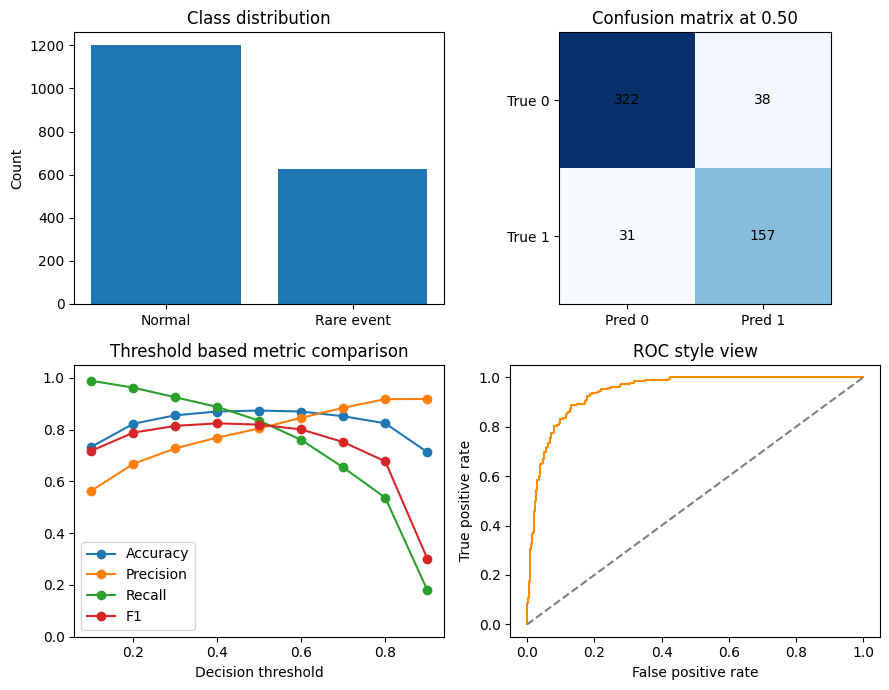

In [28]:
#@title Python Code - Metric Sensitivity

# This notebook shows metric sensitivity clearly.
# We use imbalanced satellite classes here.
# TensorFlow helps compare several metrics.

# Load required beginner friendly libraries.
import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

# Import simple sklearn helper tools.
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve

# Import simple preprocessing helpers.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set deterministic seeds for repeatability.
np.random.seed(7)
tf.random.set_seed(7)

# Print one short framework line.
print("TensorFlow version:", tf.__version__)

# Download the Landsat satellite dataset.
landsat = fetch_openml(
    name="satimage",
    version=1,
    as_frame=True
)

# Build a clean dataframe copy.
df = landsat.frame.copy()
df.columns = [str(col) for col in df.columns]

# Separate features and target labels.
X = df.iloc[:, :-1].astype("float32")
y_raw = pd.to_numeric(df.iloc[:, -1].astype("string"), errors="raise").astype("int64")

# Create a rare event class.
y = (y_raw == 4).astype(int)

# Keep all minority cases available.
minority_df = X[y == 1].copy()
minority_y = y[y == 1].copy()

# Downsample majority for stronger imbalance.
majority_df = X[y == 0].sample(
    n=1200,
    random_state=7
)
majority_y = y[y == 0].loc[majority_df.index].copy()

# Combine into one teaching dataset.
X_small = pd.concat([majority_df, minority_df], axis=0)
y_small = pd.concat([majority_y, minority_y], axis=0)

# Split data with class preservation.
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.3,
    random_state=7,
    stratify=y_small
)

# Standardize numeric feature values.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(24, activation="relu"),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile with binary classification loss.
model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Train quietly for a few epochs.
model.fit(
    X_train_scaled,
    y_train,
    epochs=12,
    batch_size=32,
    verbose=0
)

# Predict minority class probabilities.
probs = model.predict(
    X_test_scaled,
    verbose=0
).ravel()

# Use a default decision threshold.
preds_050 = (probs >= 0.50).astype(int)

# Compute key evaluation metrics.
acc = accuracy_score(y_test, preds_050)
prec = precision_score(y_test, preds_050, zero_division=0)
rec = recall_score(y_test, preds_050, zero_division=0)
f1 = f1_score(y_test, preds_050, zero_division=0)
cm = confusion_matrix(y_test, preds_050)

# Print a compact metric summary.
print("Positive class count:", int(y_small.sum()))
print("Negative class count:", int((1 - y_small).sum()))
print("Accuracy:", round(acc, 3))
print("Precision:", round(prec, 3))
print("Recall:", round(rec, 3))
print("F1 score:", round(f1, 3))
print("Confusion matrix:", cm.tolist())

# Compare metrics across thresholds.
thresholds = np.linspace(0.1, 0.9, 9)
acc_list = []
prec_list = []
rec_list = []
f1_list = []

# Fill metric lists simply.
for t in thresholds:
    preds_t = (probs >= t).astype(int)
    acc_list.append(accuracy_score(y_test, preds_t))
    prec_list.append(precision_score(y_test, preds_t, zero_division=0))
    rec_list.append(recall_score(y_test, preds_t, zero_division=0))
    f1_list.append(f1_score(y_test, preds_t, zero_division=0))

# Compute ROC style curve values.
fpr, tpr, roc_thresholds = roc_curve(y_test, probs)

# Create one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Plot class imbalance clearly.
class_counts = y_small.value_counts().sort_index()
axes[0, 0].bar(["Normal", "Rare event"], class_counts.values)
axes[0, 0].set_title("Class distribution")
axes[0, 0].set_ylabel("Count")

# Plot confusion matrix heatmap.
im = axes[0, 1].imshow(cm, cmap="Blues")
axes[0, 1].set_title("Confusion matrix at 0.50")
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_yticks([0, 1])
axes[0, 1].set_xticklabels(["Pred 0", "Pred 1"])
axes[0, 1].set_yticklabels(["True 0", "True 1"])
axes[0, 1].text(0, 0, str(cm[0, 0]), ha="center", va="center")
axes[0, 1].text(1, 0, str(cm[0, 1]), ha="center", va="center")
axes[0, 1].text(0, 1, str(cm[1, 0]), ha="center", va="center")
axes[0, 1].text(1, 1, str(cm[1, 1]), ha="center", va="center")

# Plot threshold metric sensitivity.
axes[1, 0].plot(thresholds, acc_list, marker="o", label="Accuracy")
axes[1, 0].plot(thresholds, prec_list, marker="o", label="Precision")
axes[1, 0].plot(thresholds, rec_list, marker="o", label="Recall")
axes[1, 0].plot(thresholds, f1_list, marker="o", label="F1")
axes[1, 0].set_title("Threshold based metric comparison")
axes[1, 0].set_xlabel("Decision threshold")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].legend()

# Plot ROC style interpretation.
axes[1, 1].plot(fpr, tpr, color="darkorange")
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 1].set_title("ROC style view")
axes[1, 1].set_xlabel("False positive rate")
axes[1, 1].set_ylabel("True positive rate")

# Finish the single required plot.
plt.tight_layout()
plt.show()



## **2. Missing Data Remedies**

### **2.1. Missing Data Patterns**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_02_01.jpg?v=1775521694" width="250">



>* Missingness patterns must be understood first.
>* Concentrated gaps can signal bias.

>* Missingness may be random, related, or self-linked.
>* Inspect patterns across conditions to reveal meaning.

>* Check missingness patterns before filling gaps.
>* Patterns determine suitable remedies and risks.



Rows, columns: (9357, 16)
Top missing features:
               missing_count  missing_percent
NMHC(GT)                8443             90.2
CO(GT)                  1683             18.0
NO2(GT)                 1642             17.5
NOx(GT)                 1639             17.5
C6H6(GT)                 366              3.9
PT08.S2(NMHC)            366              3.9


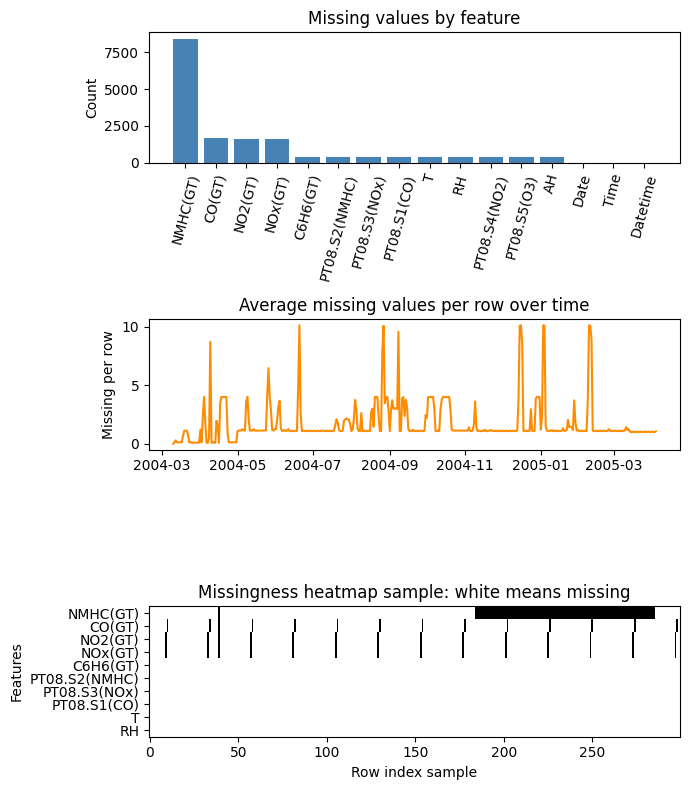

In [27]:
#@title Python Code - Missing Data Patterns

# This notebook studies missing data patterns.
# Civil engineering sensors often miss readings.
# We inspect counts, time trends, blocks.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import zipfile
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Download the air quality dataset.
!wget -q -O AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Extract the downloaded zip file.
with zipfile.ZipFile("AirQualityUCI.zip", "r") as zf:
    zf.extractall("air_quality_data")

# Load the main csv file.
file_path = os.path.join(
    "air_quality_data", "AirQualityUCI.csv"
)
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=","
)

# Remove fully empty extra columns.
df = df.dropna(axis=1, how="all")

# Replace dataset missing code values.
df = df.replace(-200, np.nan)

# Build a proper timestamp column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Keep rows with valid timestamps.
df = df[df["Datetime"].notna()].copy()
df = df.sort_values("Datetime")
df = df.reset_index(drop=True)

# Create a missingness summary table.
missing_counts = df.isna().sum()
missing_percent = (
    100 * df.isna().mean()
).round(1)
summary = pd.DataFrame(
    {
        "missing_count": missing_counts,
        "missing_percent": missing_percent
    }
)
summary = summary.sort_values(
    "missing_count", ascending=False
)

# Compute missingness over time.
row_missing = df.isna().sum(axis=1)
daily_missing = df.set_index("Datetime").isna().sum(axis=1)
daily_missing = daily_missing.resample("D").mean()

# Print a short summary table.
print("Rows, columns:", df.shape)
print("Top missing features:")
print(summary.head(6).to_string())

# Prepare a smaller heatmap sample.
heatmap_cols = summary.index[:10].tolist()
heatmap_data = df[heatmap_cols].isna().astype(int)
heatmap_data = heatmap_data.iloc[:300]

# Create one figure with three panels.
fig, axes = plt.subplots(
    3, 1, figsize=(7, 8)
)

# Plot missing counts by feature.
axes[0].bar(
    summary.index,
    summary["missing_count"],
    color="steelblue"
)
axes[0].set_title("Missing values by feature")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=75)

# Plot missingness over time.
axes[1].plot(
    daily_missing.index,
    daily_missing.values,
    color="darkorange",
    linewidth=1.5
)
axes[1].set_title("Average missing values per row over time")
axes[1].set_ylabel("Missing per row")

# Plot a heatmap style missingness view.
im = axes[2].imshow(
    heatmap_data.T,
    aspect="auto",
    cmap="binary",
    interpolation="nearest"
)
axes[2].set_title("Missingness heatmap sample: white means missing")
axes[2].set_ylabel("Features")
axes[2].set_xlabel("Row index sample")
axes[2].set_yticks(np.arange(len(heatmap_cols)))
axes[2].set_yticklabels(heatmap_cols)

# Improve spacing and show figure.
plt.tight_layout()
plt.show()



### **2.2. Basic Imputation Methods**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_02_02.jpg?v=1775521729" width="250">



>* Simple imputation fills gaps using typical values.
>* Useful for small gaps, but reduces variability.

>* Use group context for realistic imputation.
>* Use nearby times carefully in sequences.

>* Imputation choices affect predictions and risk.
>* Use transparent methods and track missingness.



TensorFlow version: 2.21.0
Pandas version: 3.0.0
Total missing values: 2285
Drop missing rows: MAE=14.34, R2=0.688
Mean imputation: MAE=9.52, R2=0.908
Median imputation: MAE=11.11, R2=0.873
Forward fill: MAE=11.36, R2=0.871


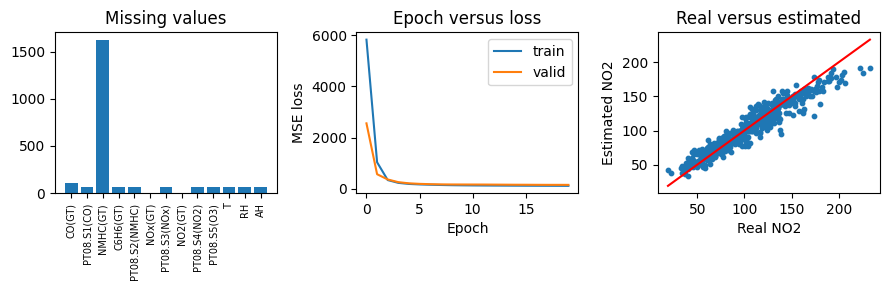

In [ ]:
#@title Python Code - Basic Imputation Methods

# This notebook shows simple missing data remedies.
# We use air quality data for regression.
# Basic imputation methods are compared clearly.

# Install lines are commented for portability.
# !pip install tensorflow==2.20.0 scikit-learn==1.8.0 gdown.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Set seeds for reproducible beginner results.
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Print short version information lines.
print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)

# Download the UCI Air Quality dataset.
url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00360/"
    "AirQualityUCI.zip"
)

# Save the compressed dataset locally.
zip_path = "AirQualityUCI.zip"
if not os.path.exists(zip_path):
    import urllib.request
    urllib.request.urlretrieve(url, zip_path)

# Extract the compressed dataset safely.
import zipfile
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall("air_quality_data")

# Read the semicolon separated file.
csv_path = "air_quality_data/AirQualityUCI.csv"
df = pd.read_csv(csv_path, sep=";", decimal=",")

# Remove empty trailing columns from file.
if "Unnamed: 15" in df.columns:
    df = df.drop(columns=["Unnamed: 15"])
if "Unnamed: 16" in df.columns:
    df = df.drop(columns=["Unnamed: 16"])

# Replace dataset missing code with NaN.
df = df.replace(-200, np.nan)

# Keep only numeric sensor columns.
numeric_cols = [
    "CO(GT)", "PT08.S1(CO)", "NMHC(GT)", "C6H6(GT)",
    "PT08.S2(NMHC)", "NOx(GT)", "PT08.S3(NOx)",
    "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]

df_num = df[numeric_cols].copy()

# Drop rows missing the prediction target.
target_col = "NO2(GT)"
df_num = df_num.dropna(subset=[target_col])

# Keep a manageable subset for speed.
df_num = df_num.iloc[:2500].copy()

# Show missing counts in one short line.
missing_total = int(df_num.isna().sum().sum())
print("Total missing values:", missing_total)

# Create three simple imputed datasets.
mean_df = df_num.copy()
median_df = df_num.copy()
ffill_df = df_num.copy()

# Fill missing values using column means.
for col in mean_df.columns:
    mean_df[col] = mean_df[col].fillna(mean_df[col].mean())

# Fill missing values using column medians.
for col in median_df.columns:
    median_df[col] = median_df[col].fillna(median_df[col].median())

# Fill missing values using forward fill.
ffill_df = ffill_df.ffill().bfill()

# Prepare a complete case baseline dataset.
complete_df = df_num.dropna().copy()

# Build a small regression neural network.
def make_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss="mse",
        metrics=["mae"]
    )
    return model

# Train and evaluate one dataset simply.
def run_case(dataframe, label):
    features = dataframe.drop(columns=[target_col]).copy()
    target = dataframe[target_col].copy()

    if len(dataframe) < 100:
        return None

    split = int(len(dataframe) * 0.8)
    x_train = features.iloc[:split].to_numpy(dtype=np.float32)
    x_test = features.iloc[split:].to_numpy(dtype=np.float32)
    y_train = target.iloc[:split].to_numpy(dtype=np.float32)
    y_test = target.iloc[split:].to_numpy(dtype=np.float32)

    train_mean = x_train.mean(axis=0)
    train_std = x_train.std(axis=0)
    train_std[train_std == 0] = 1.0

    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std

    model = make_model(x_train.shape[1])
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(x_test, verbose=0).reshape(-1)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    result = {}
    result["label"] = label
    result["history"] = history.history
    result["y_test"] = y_test
    result["preds"] = preds
    result["mae"] = float(mae)
    result["r2"] = float(r2)
    return result

# Run baseline and imputation comparisons.
results = []
base_result = run_case(complete_df, "Drop missing rows")
if base_result is not None:
    results.append(base_result)

mean_result = run_case(mean_df, "Mean imputation")
median_result = run_case(median_df, "Median imputation")
ffill_result = run_case(ffill_df, "Forward fill")

results.append(mean_result)
results.append(median_result)
results.append(ffill_result)

# Print compact performance summary lines.
for item in results:
    text = item["label"] + ":"
    text += " MAE=" + str(round(item["mae"], 2))
    text += ", R2=" + str(round(item["r2"], 3))
    print(text)

# Choose one imputed case for detailed plots.
best_result = mean_result
best_score = mean_result["mae"]

if median_result["mae"] < best_score:
    best_result = median_result
    best_score = median_result["mae"]

if ffill_result["mae"] < best_score:
    best_result = ffill_result
    best_score = ffill_result["mae"]

# Create one figure with three teaching plots.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot missing values by column.
missing_by_col = df_num.isna().sum()
axes[0].bar(range(len(missing_by_col)), missing_by_col.values)
axes[0].set_title("Missing values")
axes[0].set_xticks(range(len(missing_by_col)))
axes[0].set_xticklabels(missing_by_col.index, rotation=90, fontsize=7)

# Plot training and validation loss curves.
axes[1].plot(best_result["history"]["loss"], label="train")
axes[1].plot(best_result["history"]["val_loss"], label="valid")
axes[1].set_title("Epoch versus loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE loss")
axes[1].legend()

# Plot real versus estimated target values.
axes[2].scatter(best_result["y_test"], best_result["preds"], s=10)
min_y = float(np.min(best_result["y_test"]))
max_y = float(np.max(best_result["y_test"]))
axes[2].plot([min_y, max_y], [min_y, max_y], color="red")
axes[2].set_title("Real versus estimated")
axes[2].set_xlabel("Real NO2")
axes[2].set_ylabel("Estimated NO2")

# Finish the single required figure.
plt.tight_layout()
plt.show()



### **2.3. Outlier Treatment**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_02_03.jpg?v=1775521776" width="250">



>* Outliers can distort models and conclusions.
>* Interpret extremes using context and engineering judgment.

>* Fix errors; impute or exclude invalid outliers.
>* Cap, transform, or flag plausible extremes.

>* Use documented, context-specific outlier rules consistently.
>* Preserve meaningful extremes while reducing error impact.



TensorFlow version: 2.21.0
Rows used: 700 Removed rows: 74
Largest outlier count: age 45
MAE original: 5.3 R2: 0.79
MAE clipping: 6.91 R2: 0.69
MAE winsorizing: 5.88 R2: 0.76
MAE removal: 6.13 R2: 0.8


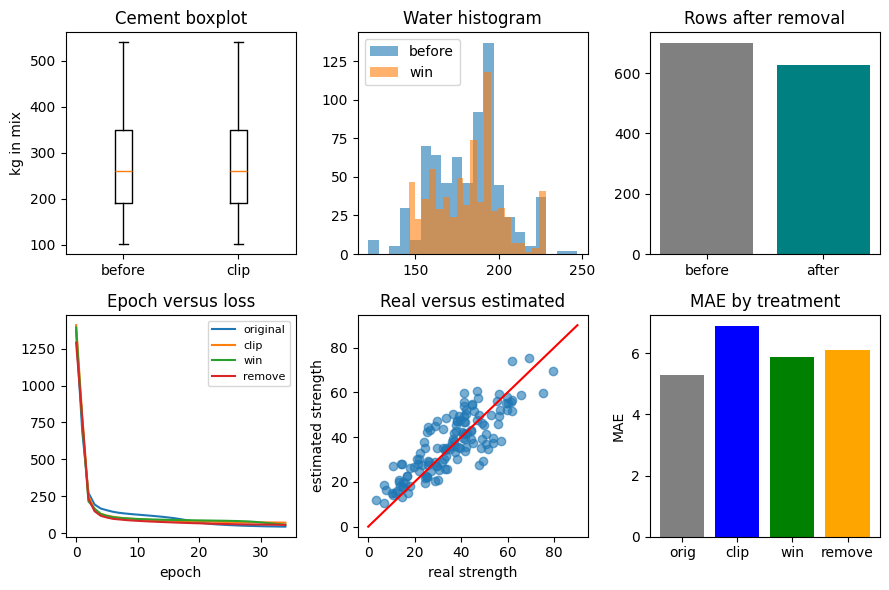

In [20]:
#@title Python Code - Outlier Treatment

# This notebook shows simple outlier treatment.
# Civil engineering data can contain extremes.
# We compare several beginner friendly fixes.

# !pip install xlrd==2.0.1

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Download the concrete strength dataset.
!wget -q -O Concrete_Data.xls \
https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Read the spreadsheet into pandas.
df = pd.read_excel("Concrete_Data.xls")
df.columns = [
    "cement", "slag", "fly_ash", "water",
    "superplasticizer", "coarse_agg", "fine_agg", "age",
    "strength"
]

# Keep a manageable sample size.
df = df.sample(n=700, random_state=7).reset_index(drop=True)

# Separate inputs and target values.
feature_names = df.columns[:-1].tolist()
target_name = "strength"
X = df[feature_names].copy()
y = df[target_name].copy()

# Count IQR outliers in each feature.
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return low, high

# Build a simple outlier summary.
outlier_counts = {}
for col in feature_names:
    low, high = iqr_bounds(X[col])
    mask = (X[col] < low) | (X[col] > high)
    outlier_counts[col] = int(mask.sum())

# Create clipping treatment.
X_clip = X.copy()
for col in feature_names:
    low, high = iqr_bounds(X[col])
    X_clip[col] = X_clip[col].clip(low, high)

# Create winsorizing treatment.
X_win = X.copy()
for col in feature_names:
    low = X[col].quantile(0.05)
    high = X[col].quantile(0.95)
    X_win[col] = X_win[col].clip(low, high)

# Create removal treatment.
keep_mask = np.ones(len(X), dtype=bool)
for col in feature_names:
    low, high = iqr_bounds(X[col])
    keep_mask = keep_mask & (X[col] >= low) & (X[col] <= high)
X_remove = X.loc[keep_mask].reset_index(drop=True)
y_remove = y.loc[keep_mask].reset_index(drop=True)

# Standardize using training statistics.
def scale_sets(X_train, X_test):
    mean = X_train.mean()
    std = X_train.std().replace(0, 1)
    X_train_s = (X_train - mean) / std
    X_test_s = (X_test - mean) / std
    return X_train_s, X_test_s

# Build a small TensorFlow regressor.
def make_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss="mse"
    )
    return model

# Train and evaluate one treatment.
def run_case(X_data, y_data, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=7
    )
    X_train_s, X_test_s = scale_sets(X_train, X_test)
    model = make_model(X_train_s.shape[1])
    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=35,
        batch_size=32,
        verbose=0
    )
    preds = model.predict(X_test_s, verbose=0).flatten()
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return history, y_test, preds, mae, r2, label

# Run all treatment options.
base_result = run_case(X, y, "original")
clip_result = run_case(X_clip, y, "clipping")
win_result = run_case(X_win, y, "winsorizing")
remove_result = run_case(X_remove, y_remove, "removal")

# Print a short summary only.
print("TensorFlow version:", tf.__version__)
print("Rows used:", len(df), "Removed rows:", int((~keep_mask).sum()))
print("Largest outlier count:", max(outlier_counts, key=outlier_counts.get), max(outlier_counts.values()))
print("MAE original:", round(base_result[3], 2), "R2:", round(base_result[4], 2))
print("MAE clipping:", round(clip_result[3], 2), "R2:", round(clip_result[4], 2))
print("MAE winsorizing:", round(win_result[3], 2), "R2:", round(win_result[4], 2))
print("MAE removal:", round(remove_result[3], 2), "R2:", round(remove_result[4], 2))

# Prepare one figure with all comparisons.
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

# Show boxplots before and after clipping.
axes[0, 0].boxplot([X["cement"], X_clip["cement"]], labels=["before", "clip"])
axes[0, 0].set_title("Cement boxplot")
axes[0, 0].set_ylabel("kg in mix")

# Show histograms before and after winsorizing.
axes[0, 1].hist(X["water"], bins=20, alpha=0.6, label="before")
axes[0, 1].hist(X_win["water"], bins=20, alpha=0.6, label="win")
axes[0, 1].set_title("Water histogram")
axes[0, 1].legend()

# Compare row counts after removal.
axes[0, 2].bar(["before", "after"], [len(X), len(X_remove)], color=["gray", "teal"])
axes[0, 2].set_title("Rows after removal")

# Plot training loss curves.
axes[1, 0].plot(base_result[0].history["loss"], label="original")
axes[1, 0].plot(clip_result[0].history["loss"], label="clip")
axes[1, 0].plot(win_result[0].history["loss"], label="win")
axes[1, 0].plot(remove_result[0].history["loss"], label="remove")
axes[1, 0].set_title("Epoch versus loss")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend(fontsize=8)

# Plot real versus estimated values.
axes[1, 1].scatter(clip_result[1], clip_result[2], alpha=0.6)
axes[1, 1].plot([0, 90], [0, 90], color="red")
axes[1, 1].set_title("Real versus estimated")
axes[1, 1].set_xlabel("real strength")
axes[1, 1].set_ylabel("estimated strength")

# Show MAE comparison across treatments.
mae_values = [base_result[3], clip_result[3], win_result[3], remove_result[3]]
labels = ["orig", "clip", "win", "remove"]
axes[1, 2].bar(labels, mae_values, color=["gray", "blue", "green", "orange"])
axes[1, 2].set_title("MAE by treatment")
axes[1, 2].set_ylabel("MAE")

# Finish the figure neatly.
plt.tight_layout()
plt.show()



## **3. Monitoring Data Drift**

### **3.1. Historical Data Comparison**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_03_01.jpg?v=1775521828" width="250">



>* Compare new data with training baseline.
>* Detect changing conditions before model reliability drops.

>* Choose a stable baseline and tracked features.
>* Compare new batches for meaningful distribution changes.

>* Regular comparisons give early drift warnings.
>* They support trust and long-term model use.



replace AirQualityUCI.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Historical rows: 4858
New rows: 2083
Features checked: CO(GT), NO2(GT), T, RH
         historical_mean  new_mean  mean_change_pct
CO(GT)              2.22      2.10             -5.4
NO2(GT)           101.48    142.77             40.7
T                  20.97     10.25            -51.1
RH                 47.37     52.42             10.7


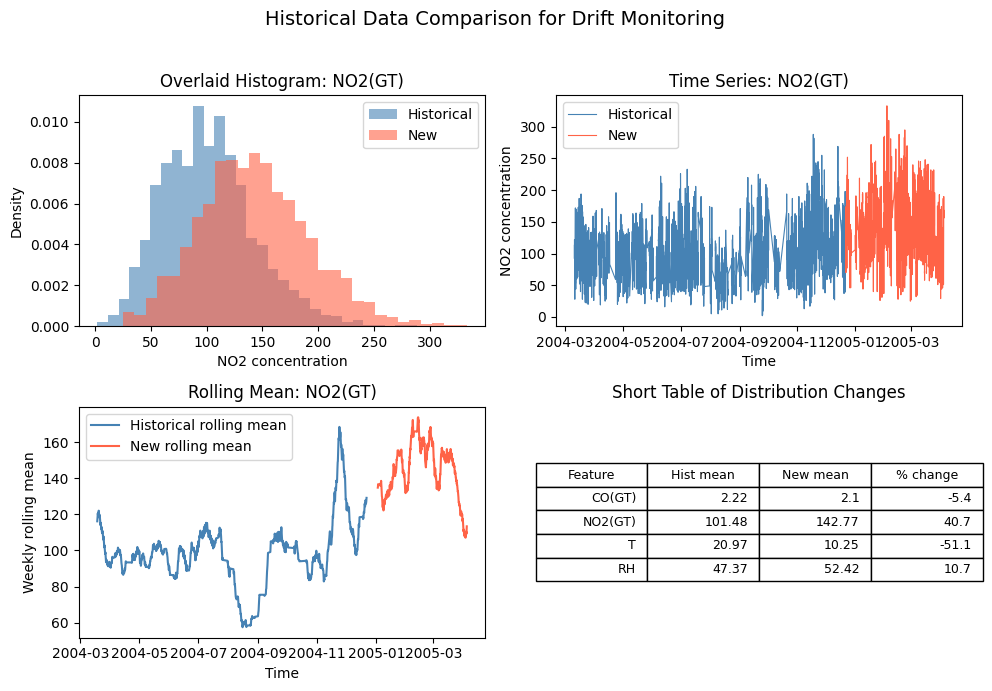

In [ ]:
#@title Python Code - Historical Data Comparison

# Compare historical and new monitoring data.
# This example shows simple drift checks.
# Air quality acts like sensor data.

# Load core libraries for analysis.
import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a seed for repeatability.
np.random.seed(7)
!wget -q -O AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
!unzip -q AirQualityUCI.zip  

# Read the zipped dataset directly.
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# Remove empty helper columns.
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df = df.replace(-200, np.nan)

# Build a proper timestamp column.
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

# Keep rows with valid timestamps.
df = df.dropna(subset=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Choose a few important features.
features = [
    'CO(GT)',
    'NO2(GT)',
    'T',
    'RH'
]

# Keep rows with enough data.
df = df[['Datetime'] + features].copy()
df = df.dropna(subset=features)

# Split into historical and new periods.
split_index = int(len(df) * 0.7)
historical = df.iloc[:split_index].copy()
new_data = df.iloc[split_index:].copy()

# Check that both periods exist.
if len(historical) == 0 or len(new_data) == 0:
    raise ValueError('Data split failed for comparison.')

# Create a short drift summary table.
summary = pd.DataFrame(index=features)
summary['historical_mean'] = historical[features].mean().round(2)
summary['new_mean'] = new_data[features].mean().round(2)
summary['mean_change_pct'] = (
    (summary['new_mean'] - summary['historical_mean'])
    / summary['historical_mean'].replace(0, np.nan) * 100
).round(1)

# Add spread and missing checks.
summary['historical_std'] = historical[features].std().round(2)
summary['new_std'] = new_data[features].std().round(2)
summary['std_change_pct'] = (
    (summary['new_std'] - summary['historical_std'])
    / summary['historical_std'].replace(0, np.nan) * 100
).round(1)

# Print a compact teaching summary.
print('Historical rows:', len(historical))
print('New rows:', len(new_data))
print('Features checked:', ', '.join(features))
print(summary[['historical_mean', 'new_mean', 'mean_change_pct']])

# Prepare rolling averages for monitoring.
roll_window = 24 * 7
hist_roll = historical.set_index('Datetime')[features].rolling(roll_window).mean()
new_roll = new_data.set_index('Datetime')[features].rolling(roll_window).mean()

# Create one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Historical Data Comparison for Drift Monitoring', fontsize=14)

# Plot overlaid histograms for one feature.
axes[0, 0].hist(
    historical['NO2(GT)'],
    bins=30,
    alpha=0.6,
    label='Historical',
    color='steelblue',
    density=True)

axes[0, 0].hist(
    new_data['NO2(GT)'],
    bins=30,
    alpha=0.6,
    label='New',
    color='tomato',
    density=True)

axes[0, 0].set_title('Overlaid Histogram: NO2(GT)')
axes[0, 0].set_xlabel('NO2 concentration')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# Plot time series for one feature.
axes[0, 1].plot(
    historical['Datetime'],
    historical['NO2(GT)'],
    color='steelblue',
    linewidth=0.8,
    label='Historical')

axes[0, 1].plot(
    new_data['Datetime'],
    new_data['NO2(GT)'],
    color='tomato',
    linewidth=0.8,
    label='New')

axes[0, 1].set_title('Time Series: NO2(GT)')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('NO2 concentration')
axes[0, 1].legend()

# Plot rolling mean for one feature.
axes[1, 0].plot(
    hist_roll.index,
    hist_roll['NO2(GT)'],
    color='steelblue',
    linewidth=1.5,
    label='Historical rolling mean')

axes[1, 0].plot(
    new_roll.index,
    new_roll['NO2(GT)'],
    color='tomato',
    linewidth=1.5,
    label='New rolling mean')

axes[1, 0].set_title('Rolling Mean: NO2(GT)')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Weekly rolling mean')
axes[1, 0].legend()

# Show a compact table inside the figure.
axes[1, 1].axis('off')
table_data = summary.reset_index()
table_data = table_data[
    ['index', 'historical_mean', 'new_mean', 'mean_change_pct']]

table_data.columns = ['Feature', 'Hist mean', 'New mean', '% change']
plot_table = axes[1, 1].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center')

plot_table.auto_set_font_size(False)
plot_table.set_fontsize(9)
plot_table.scale(1.1, 1.5)
axes[1, 1].set_title('Short Table of Distribution Changes')

# Finish the figure neatly.
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



### **3.2. Basic Drift Tests**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_03_02.jpg?v=1775521870" width="250">



>* Compare new inputs with historical distributions.
>* Drift tests give early warning signs.

>* Use simple, regular drift checks over time.
>* Track shifts into unfamiliar data ranges.

>* Interpret drift using context and routine review.
>* Set thresholds with engineering judgment and logs.



Rows used: 9017  Window size: 500
Historical dates: 2004-03-10 to 2004-03-31
New dates: 2005-03-14 to 2005-04-04
Flagged features: 8 out of 13
      feature  hist_mean  new_mean  hist_overlap  shift_score  flag
       CO(GT)      2.293     2.031         0.853        0.523 False
  PT08.S1(CO)   1223.038  1152.400         0.870        0.932  True
     NMHC(GT)    170.161       NaN           NaN          NaN False
     C6H6(GT)      9.943     8.678         0.858        0.751 False
PT08.S2(NMHC)    935.424   883.138         0.858        0.783 False
      NOx(GT)    143.906   282.292         0.650        6.694  True
 PT08.S3(NOx)   1031.834   689.450         0.492        4.111  True
      NO2(GT)    102.613   127.010         0.754        2.722  True


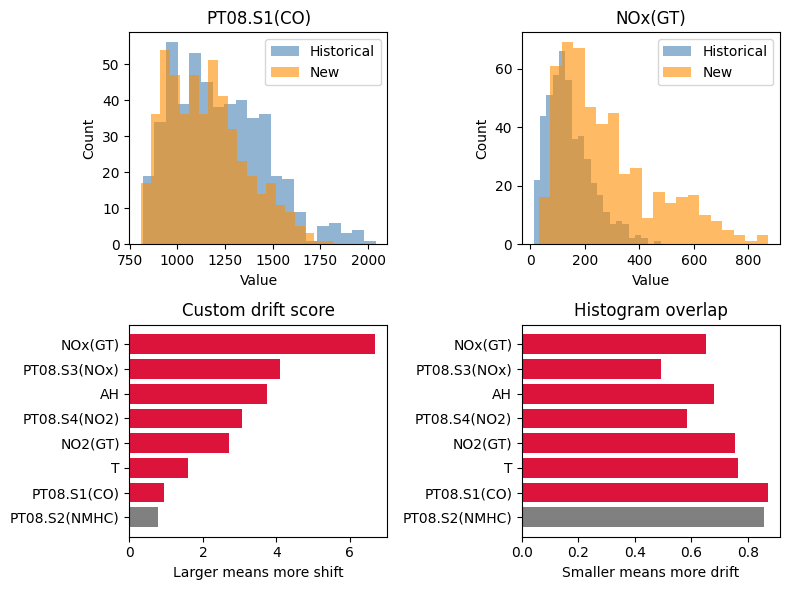

In [ ]:
#@title Python Code - Basic Drift Tests

# Basic drift tests for monitoring data changes.
# This example uses the UCI Air Quality dataset.
# Civil engineering students can inspect simple warnings.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set deterministic seeds for repeatable results.
np.random.seed(7)

# Download the dataset quietly.
!wget -q -O AirQualityUCI.zip "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
!unzip -oq AirQualityUCI.zip

# Load the main csv file.
df = pd.read_csv(
    "AirQualityUCI.csv",
    sep=";",
    decimal=",",
    na_values=[-200]
)

# Remove empty helper columns.
df = df.dropna(axis=1, how="all")

# Build a timestamp column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Keep rows with valid time.
df = df.dropna(subset=["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

# Select numeric sensor features.
feature_names = [
    "CO(GT)", "PT08.S1(CO)", "NMHC(GT)",
    "C6H6(GT)", "PT08.S2(NMHC)",
    "NOx(GT)", "PT08.S3(NOx)",
    "NO2(GT)", "PT08.S4(NO2)",
    "PT08.S5(O3)", "T",
    "RH","AH"
]

# Keep available numeric columns only.
usable_features = []
for name in feature_names:
    if name in df.columns:
        usable_features.append(name)

# Convert selected columns to numeric.
for name in usable_features:
    df[name] = pd.to_numeric(df[name], errors="coerce")

# Keep rows with enough numeric data.
valid_counts = df[usable_features].notna().sum(axis=1)
df = df.loc[valid_counts >= 4].copy()

# Create historical and new windows.
window_size = 500
if len(df) < 2 * window_size:
    window_size = max(100, len(df) // 3)

# Slice the two comparison windows.
historical = df.iloc[:window_size].copy()
new_data = df.iloc[-window_size:].copy()

# Define simple helper functions.
def histogram_overlap(a, b, bins=12):
    both = pd.concat([a, b], axis=0).dropna()
    if len(both) < 10:
        return np.nan
    edges = np.histogram_bin_edges(both, bins=bins)
    ha, _ = np.histogram(a.dropna(), bins=edges, density=True)
    hb, _ = np.histogram(b.dropna(), bins=edges, density=True)
    widths = np.diff(edges)
    return np.sum(np.minimum(ha, hb) * widths)

# Define a custom two sample score.
def custom_shift_score(a, b):
    a = a.dropna()
    b = b.dropna()
    if len(a) < 10 or len(b) < 10:
        return np.nan
    mean_gap = abs(a.mean() - b.mean())
    scale = a.std() + 1e-6
    p50_gap = abs(a.quantile(0.50) - b.quantile(0.50))
    p90_gap = abs(a.quantile(0.90) - b.quantile(0.90))
    return mean_gap / scale + p50_gap / scale + p90_gap / scale

# Compare each feature across windows.
rows = []
for name in usable_features:
    old = historical[name]
    new = new_data[name]
    old_mean = old.mean()
    new_mean = new.mean()

    old_var = old.var()
    new_var = new.var()
    mean_ratio = abs(new_mean - old_mean) / (abs(old_mean) + 1e-6)
    var_ratio = abs(new_var - old_var) / (abs(old_var) + 1e-6)

    p10_old = old.quantile(0.10)
    p10_new = new.quantile(0.10)
    p50_old = old.quantile(0.50)
    p50_new = new.quantile(0.50)
    p90_old = old.quantile(0.90)
    p90_new = new.quantile(0.90)

    overlap = histogram_overlap(old, new, bins=12)
    score = custom_shift_score(old, new)

    flag = False
    if mean_ratio > 0.20:
        flag = True
    if var_ratio > 0.30:
        flag = True
    if pd.notna(overlap) and overlap < 0.70:
        flag = True
    if pd.notna(score) and score > 0.80:
        flag = True

    rows.append([
        name, old_mean, new_mean, old_var, new_var,
        p10_old, p10_new, p50_old, p50_new,
        p90_old, p90_new, overlap, score, flag
    ])

# Build a compact summary table.
summary = pd.DataFrame(
    rows,
    columns=[
        "feature", "hist_mean", "new_mean", "hist_var", "new_var",
        "hist_p10", "new_p10", "hist_p50", "new_p50",
        "hist_p90", "new_p90", "hist_overlap", "shift_score", "flag"
    ]
)

# Round values for cleaner display.
show_cols = [
    "feature", "hist_mean", "new_mean",
    "hist_overlap", "shift_score", "flag"
]
summary_show = summary[show_cols].copy()
summary_show = summary_show.round(3)

# Print a short teaching summary.
print("Rows used:", len(df), " Window size:", window_size)
print("Historical dates:", historical["Datetime"].min().date(), "to", historical["Datetime"].max().date())
print("New dates:", new_data["Datetime"].min().date(), "to", new_data["Datetime"].max().date())
print("Flagged features:", int(summary["flag"].sum()), "out of", len(summary))
print(summary_show.head(8).to_string(index=False))

# Choose features for plotting.
flagged = summary.loc[summary["flag"], "feature"].tolist()
if len(flagged) >= 2:
    plot_features = flagged[:2]
else:
    ranked = summary.sort_values("shift_score", ascending=False)
    plot_features = ranked["feature"].head(2).tolist()

# Create one figure with histograms and flags.
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Plot side by side histograms.
for i in range(2):
    name = plot_features[i]
    axes[0, i].hist(
        historical[name].dropna(), bins=20,
        alpha=0.6, label="Historical", color="steelblue"
    )

    axes[0, i].hist(
        new_data[name].dropna(), bins=20,
        alpha=0.6, label="New", color="darkorange"
    )
    
    axes[0, i].set_title(name)
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Count")
    axes[0, i].legend()

# Plot flagged feature scores.
plot_table = summary.sort_values("shift_score", ascending=False).head(8)
colors = []
for value in plot_table["flag"]:
    if value:
        colors.append("crimson")
    else:
        colors.append("gray")

# Draw the score bar chart.
axes[1, 0].barh(plot_table["feature"], plot_table["shift_score"], color=colors)
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Custom drift score")
axes[1, 0].set_xlabel("Larger means more shift")

# Plot histogram overlap values.
axes[1, 1].barh(plot_table["feature"], plot_table["hist_overlap"], color=colors)
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Histogram overlap")
axes[1, 1].set_xlabel("Smaller means more drift")

# Finish the single figure.
plt.tight_layout()
plt.show()



### **3.3. Retraining Triggers**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_A/image_03_03.jpg?v=1775521915" width="250">



>* Retraining rules handle changing civil data.
>* Use measurable drift or performance signals.

>* Combine persistent drift and error evidence.
>* Use duration thresholds to avoid retraining.

>* Set triggers by model risk level.
>* Use seasonal, infrastructure, and periodic reviews.



TensorFlow version: 2.21.0
Device used: CPU
Baseline validation MAE: 0.264
Later test MAE: 0.32
Average drift score: 0.323
MAE increase ratio: 1.214
Retraining trigger: NO


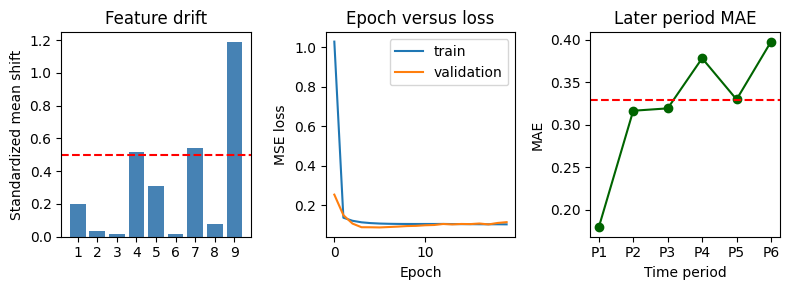

In [16]:
#@title Python Code - Retraining Triggers

# Monitor drift with simple retraining rules.
# Use air quality data over time.
# Build a small TensorFlow baseline model.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from sklearn.metrics import mean_absolute_error

# Set seeds for repeatable results.
np.random.seed(7)
random.seed(7)
tf.random.set_seed(7)

# Print one short version line.
print("TensorFlow version:", tf.__version__)

# Download the UCI air quality dataset.
!wget -q -O AirQualityUCI.zip "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
!unzip -o -q AirQualityUCI.zip

# Load the semicolon separated file.
file_name = "AirQualityUCI.csv"
df = pd.read_csv(file_name, sep=";", decimal=",")

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how="all")
if "Date" not in df.columns:
    raise ValueError("Date column missing")

# Build a timestamp for ordering.
df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Replace dataset missing markers.
df = df.replace(-200, np.nan)
df = df.sort_values("timestamp")
df = df.dropna(subset=["timestamp"])

# Keep useful numeric columns only.
keep_cols = [
    "CO(GT)", "PT08.S1(CO)", "NMHC(GT)", "C6H6(GT)",
    "PT08.S2(NMHC)", "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"
]

df = df[["timestamp"] + keep_cols]
df = df.dropna(subset=["CO(GT)"])

# Fill remaining missing values simply.
for col in keep_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Keep a manageable clean subset.
df = df.iloc[:4000].copy()
df = df.reset_index(drop=True)
if len(df) < 800:
    raise ValueError("Dataset too small")

# Define features and target.
feature_cols = [
    "PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)",
    "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]
target_col = "CO(GT)"

# Split earlier and later periods.
train_end = int(len(df) * 0.60)
val_end = int(len(df) * 0.75)
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# Standardize using training statistics.
train_means = train_df[feature_cols].mean()
train_stds = train_df[feature_cols].std().replace(0, 1)
X_train = (train_df[feature_cols] - train_means) / train_stds
X_val = (val_df[feature_cols] - train_means) / train_stds
X_test = (test_df[feature_cols] - train_means) / train_stds

y_train = train_df[target_col].to_numpy(dtype="float32")
y_val = val_df[target_col].to_numpy(dtype="float32")
y_test = test_df[target_col].to_numpy(dtype="float32")

# Convert arrays for TensorFlow.
X_train = X_train.to_numpy(dtype="float32")
X_val = X_val.to_numpy(dtype="float32")
X_test = X_test.to_numpy(dtype="float32")

# Choose GPU if available.
device_name = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print("Device used:", device_name)

# Build a small regression model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(feature_cols),)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile the model quietly.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

# Train on earlier data only.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=0
)

# Evaluate baseline and later performance.
val_pred = model.predict(X_val, verbose=0).flatten()
test_pred = model.predict(X_test, verbose=0).flatten()
base_mae = mean_absolute_error(y_val, val_pred)
later_mae = mean_absolute_error(y_test, test_pred)

# Measure simple feature drift magnitude.
drift_scores = []
for col in feature_cols:
    train_mean = train_df[col].mean()
    later_mean = test_df[col].mean()
    train_std = train_df[col].std()
    if pd.isna(train_std) or train_std == 0:
        train_std = 1.0
    score = abs(later_mean - train_mean) / train_std
    drift_scores.append(score)

# Summarize drift and decay.
avg_drift = float(np.mean(drift_scores))
mae_ratio = float(later_mae / max(base_mae, 1e-6))

# Define practical retraining thresholds.
drift_threshold = 0.50
mae_ratio_threshold = 1.25
retrain_flag = False
if avg_drift > drift_threshold:
    retrain_flag = True
if mae_ratio > mae_ratio_threshold:
    retrain_flag = True

# Compute period by period later errors.
period_count = 6
period_edges = np.linspace(0, len(test_df), period_count + 1, dtype=int)
period_labels = []
period_mae = []
for i in range(period_count):
    start_i = period_edges[i]
    end_i = period_edges[i + 1]
    if end_i - start_i < 5:
        continue
    y_true_part = y_test[start_i:end_i]
    y_pred_part = test_pred[start_i:end_i]
    mae_part = mean_absolute_error(y_true_part, y_pred_part)
    period_mae.append(mae_part)
    period_labels.append("P" + str(i + 1))

# Print a short monitoring summary.
print("Baseline validation MAE:", round(base_mae, 3))
print("Later test MAE:", round(later_mae, 3))
print("Average drift score:", round(avg_drift, 3))
print("MAE increase ratio:", round(mae_ratio, 3))
print("Retraining trigger:", "YES" if retrain_flag else "NO")

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# Plot feature drift scores.
axes[0].bar(range(len(feature_cols)), drift_scores, color="steelblue")
axes[0].axhline(drift_threshold, color="red", linestyle="--")
axes[0].set_title("Feature drift")
axes[0].set_xticks(range(len(feature_cols)))
axes[0].set_xticklabels(range(1, len(feature_cols) + 1), rotation=0)
axes[0].set_ylabel("Standardized mean shift")

# Plot epoch losses.
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Epoch versus loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE loss")
axes[1].legend()

# Plot later period performance.
axes[2].plot(period_labels, period_mae, marker="o", color="darkgreen")
axes[2].axhline(base_mae * mae_ratio_threshold, color="red", linestyle="--")
axes[2].set_title("Later period MAE")
axes[2].set_xlabel("Time period")
axes[2].set_ylabel("MAE")

# Finish the single required plot.
plt.tight_layout()
plt.show()



# <font color="#418FDE" size="6.5" uppercase>**Data Issues and Fixes**</font>


In this lecture, you learned to:
- Diagnose data quality problems such as imbalance, outliers, noise, and drift in CE datasets. 
- Apply basic remediation techniques to improve model training data. 
- Design simple checks to monitor data distributions over time for deployed CE models. 

In the next Lecture (Lecture B), we will go over 'Training Stability and Risk'